# Progetto 1

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

1. Data Exploration & Preprocessing

- Caricamento e Analisi: Caricare il dataset e fornire un'analisi descrittiva iniziale (es. df.describe())
- Standardizzazione: Applicare la standardizzazione alle feature ($X$) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria

In [34]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)

print(df.head())
print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean            5.843333          3.057333           3.758000          1.199333
std             0.828066          0.435866           1.765298          0.762238
min             4.300000          2.000000           1.000000          0.100000
25%             5.100000          2.800000           1.600000          0.300000
50%             5.800000          3.000000           4.350000   

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. Stima di $K$ con DBSCAN
- Parametri di Iterazione:
    - min_samples = 5
    - eps [0.35, 0.45, 0.55]
- Metriche da determinare per ogni esecuzione:
    - Numero di cluster
    - Numero di punti rumorosi (label -1)
- Individuare il numero di cluster più plausibile tra i risultati ottenuti

In [36]:
min_samples = 5
eps_values = [0.35, 0.45, 0.55]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    unique_labels = set(labels)
    if -1 in unique_labels:
        n_clusters = len(unique_labels) - 1
    else:
        n_clusters = len(unique_labels)

    n_noise = list(labels).count(-1)

    print(f"Parametri: eps = {eps} | min_samples = {min_samples}")
    print(f" -> Numero di cluster identificati (K): {n_clusters}")
    print(f" -> Numero di punti rumorosi (label -1): {n_noise}")
    print("-" * 50)

Parametri: eps = 0.35 | min_samples = 5
 -> Numero di cluster identificati (K): 4
 -> Numero di punti rumorosi (label -1): 104
--------------------------------------------------
Parametri: eps = 0.45 | min_samples = 5
 -> Numero di cluster identificati (K): 3
 -> Numero di punti rumorosi (label -1): 54
--------------------------------------------------
Parametri: eps = 0.55 | min_samples = 5
 -> Numero di cluster identificati (K): 2
 -> Numero di punti rumorosi (label -1): 29
--------------------------------------------------


L'algoritmo tende ad identificare 2 Cluster (K) stabili osservando il numero minore di punti rumorosi 

3. Stima di $K$ con Elbow Method:
- Algoritmo: K-Means
- Range di K: da 1 a 10
- Visualizzazione: 
    - Plot del grafico dell'Elbow Method (Inerzia su asse Y e K su asse X). 
    - Identificazione del "punto di gomito". 
    - Inserimento di un asse verticale in corrispondenza del valore K scelto

In [37]:
k_range = range(1, 11)
inertia_values = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

k_ottimale = 3

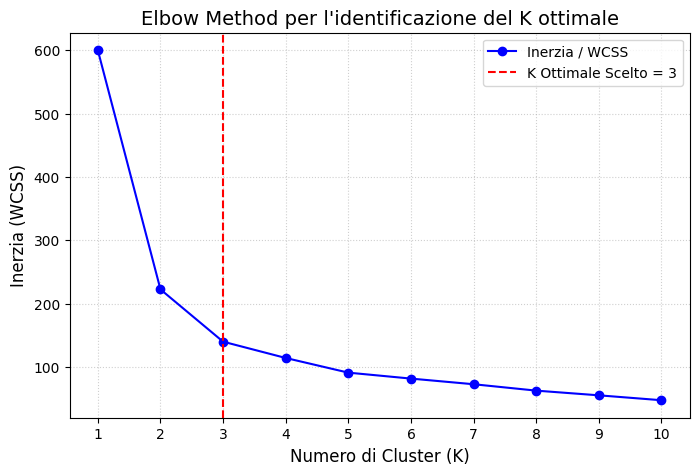

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='b', label='Inerzia / WCSS')
plt.axvline(x=k_ottimale, color='r', linestyle='--', label=f'K Ottimale Scelto = {k_ottimale}')

plt.title("Elbow Method per l'identificazione del K ottimale", fontsize=14)
plt.xlabel("Numero di Cluster (K)", fontsize=12)
plt.ylabel("Inerzia (WCSS)", fontsize=12)
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

4. Applicazione Finale & Visualizzazione
- Clusterizzazione: Stabilire il $K$ finale e applicare il K-Means sul dataset standardizzato
- Valutazione: Calcolare Silhouette Score per valutare la coesione interna e la separazione dei cluster
- Visualizzazione risultati: 
    - Plot dei dati in 2D (utilizzando prime due feature)
    - Rappresentazione dei centroidi dei cluster

In [39]:
kmeans_final = KMeans(n_clusters=k_ottimale, random_state=42, n_init=10)
final_labels = kmeans_final.fit_predict(X_scaled)
centroids = kmeans_final.cluster_centers_

In [40]:
sil_score = silhouette_score(X_scaled, final_labels)
print(f"Silhouette Score per K={k_ottimale}: {sil_score:.4f}")

Silhouette Score per K=3: 0.4599


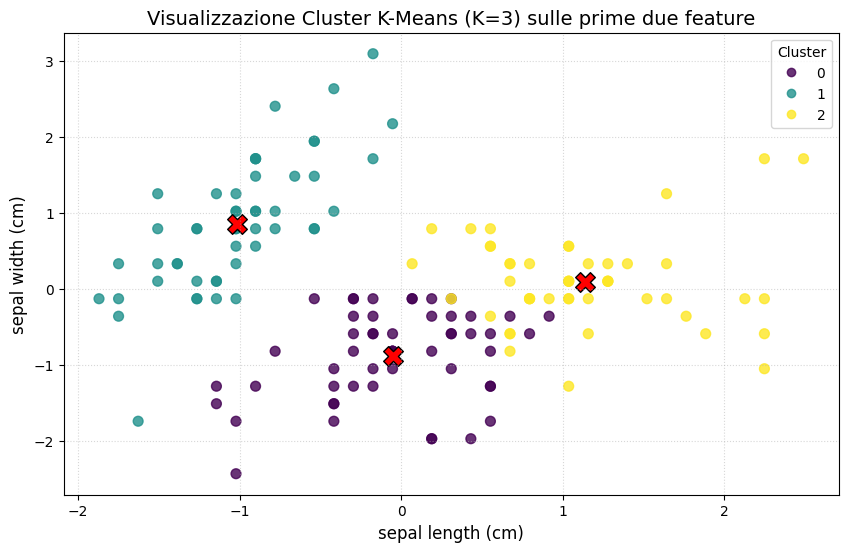

In [41]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=final_labels, cmap='viridis', s=50, alpha=0.8, label='Punti Dati')

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black', label='Centroidi')

plt.title(f"Visualizzazione Cluster K-Means (K={k_ottimale}) sulle prime due feature", fontsize=14)
plt.xlabel(feature_names[0], fontsize=12)
plt.ylabel(feature_names[1], fontsize=12)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()